1. Data Acquisition and Initial Inspection

In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
from pathlib import Path

# Define the dataset path
data_path = Path("D:/Tasks/week1/raw/heart.csv")

# Load the original dataset
df = pd.read_csv(data_path)

# Display the first five records
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Display the number of rows
print("Number of records:", df.shape[0])

# Display the number of columns
print("Number of columns:", df.shape[1])

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display the data types and non-null counts
print("\nDataset information:")
df.info()

Number of records: 303
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Display the unique values in categorical columns
categorical_columns = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal", "target"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(sorted(df[column].dropna().unique()))


sex:
[np.int64(0), np.int64(1)]

cp:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

fbs:
[np.int64(0), np.int64(1)]

restecg:
[np.int64(0), np.int64(1), np.int64(2)]

exang:
[np.int64(0), np.int64(1)]

slope:
[np.int64(0), np.int64(1), np.int64(2)]

ca:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

thal:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

target:
[np.int64(0), np.int64(1)]


2. Missing Value Analysis

In [5]:
# Count missing values in every column
missing_counts = df.isnull().sum()

print("Missing values by column:")
print(missing_counts)

# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing-value percentage:")
print(missing_percentage.round(2))

Missing values by column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing-value percentage:
age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


In [10]:
# Create a working copy of the original dataset
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Check the result
print("Original number of rows:", len(df))
print("Rows after duplicate removal:", len(df_clean))
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Original number of rows: 303
Rows after duplicate removal: 302
Remaining duplicate rows: 0


4. Data Validation and Consistency Checks

In [11]:
# Display descriptive statistics for numerical columns
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [12]:
# Review the values allowed by the observed data
categorical_columns = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal", "target"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts().sort_index())


sex
sex
0     96
1    206
Name: count, dtype: int64

cp
cp
0    143
1     50
2     86
3     23
Name: count, dtype: int64

fbs
fbs
0    257
1     45
Name: count, dtype: int64

restecg
restecg
0    147
1    151
2      4
Name: count, dtype: int64

exang
exang
0    203
1     99
Name: count, dtype: int64

slope
slope
0     21
1    140
2    141
Name: count, dtype: int64

ca
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal
thal
0      2
1     18
2    165
3    117
Name: count, dtype: int64

target
target
0    138
1    164
Name: count, dtype: int64


In [13]:
# Flag values that need investigation
checks = {
    "age_below_zero": df_clean["age"] < 0,
    "negative_blood_pressure": df_clean["trestbps"] < 0,
    "negative_cholesterol": df_clean["chol"] < 0,
    "negative_max_heart_rate": df_clean["thalach"] < 0,
    "negative_oldpeak": df_clean["oldpeak"] < 0,
    "target_outside_0_1": ~df_clean["target"].isin([0, 1])
}

for name, condition in checks.items():
    print(f"{name}: {condition.sum()} records flagged")

age_below_zero: 0 records flagged
negative_blood_pressure: 0 records flagged
negative_cholesterol: 0 records flagged
negative_max_heart_rate: 0 records flagged
negative_oldpeak: 0 records flagged
target_outside_0_1: 0 records flagged


5. Outlier Analysis

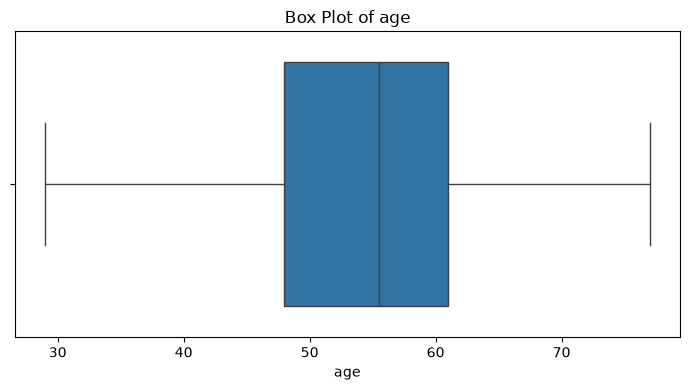

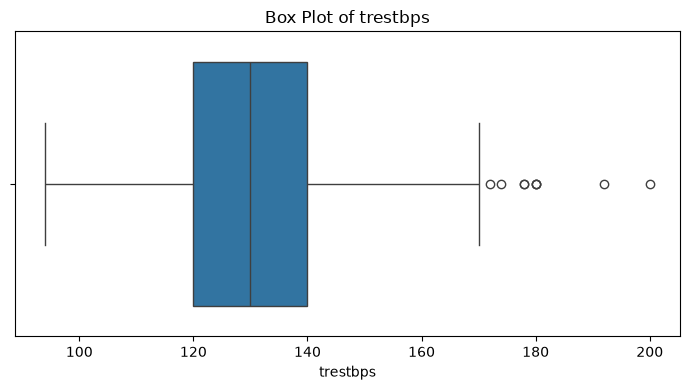

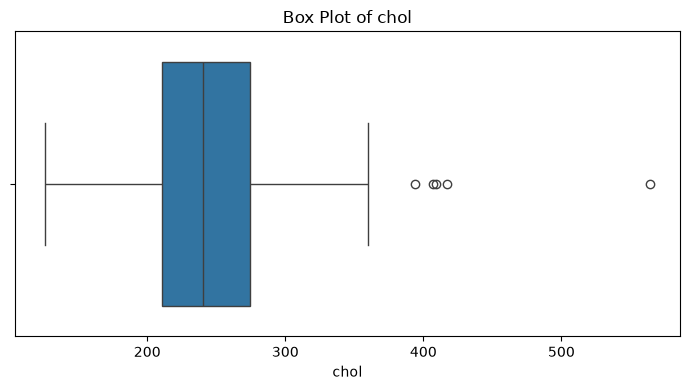

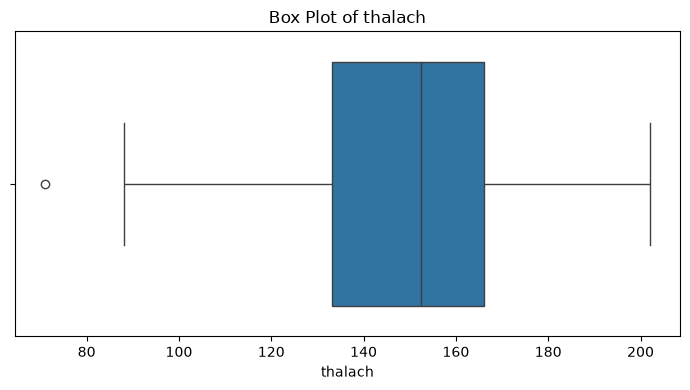

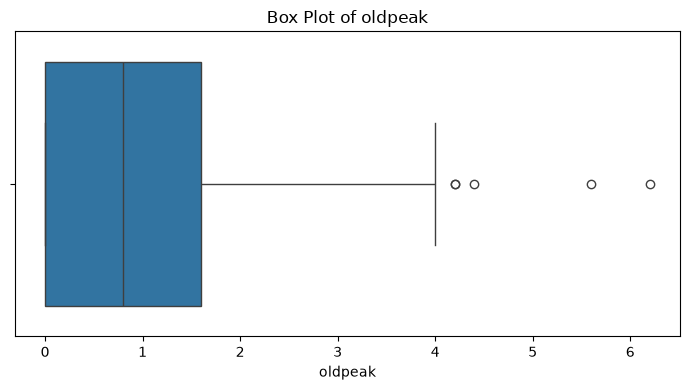

In [33]:
# Select numerical measurements for outlier inspection
numerical_columns = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

for column in numerical_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df_clean[column])

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)

    plt.tight_layout()

    plt.savefig(
        f"visualizations/boxplot_{column}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [15]:
# Identify possible outliers using the IQR rule
outlier_summary = []

for column in numerical_columns:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Column,Lower Bound,Upper Bound,Potential Outliers
0,age,28.500,80.500,0
1,trestbps,90.000,170.000,9
2,chol,115.375,370.375,5
3,thalach,84.125,215.125,1
4,oldpeak,-2.400,4.000,5


6. Data Type Assessment and Preprocessing

In [16]:
# Display current data types
print(df_clean.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [17]:
# These columns represent categories encoded as numbers
categorical_columns = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal", "target"
]

# Keep the original numeric codes but use category data types
df_clean[categorical_columns] = (
    df_clean[categorical_columns].astype("category")
)

# Verify the changes
print(df_clean.dtypes)

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
target      category
dtype: object


In [18]:
# Define the output directory
output_dir = Path("D:/Tasks/week1/processed")

# Create the directory if it does not exist
output_dir.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataset
df_clean.to_csv(
    output_dir / "heart_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [19]:
# Reload the cleaned dataset
verified_df = pd.read_csv(
    output_dir / "heart_cleaned.csv"
)

# Verify the saved file
print("Shape:", verified_df.shape)
print("Missing values:", verified_df.isnull().sum().sum())
print("Duplicate rows:", verified_df.duplicated().sum())

display(verified_df.head())

Shape: (302, 14)
Missing values: 0
Duplicate rows: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
# Compare the original and cleaned datasets
comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        verified_df.shape[0],
        verified_df.shape[1],
        verified_df.isnull().sum().sum(),
        verified_df.duplicated().sum()
    ]
})

display(comparison)

,Metric,Before Cleaning,After Cleaning
0,Rows,303,302
1,Columns,14,14
2,Missing Values,0,0
3,Duplicate Rows,1,0


8. Exploratory Data Analysis

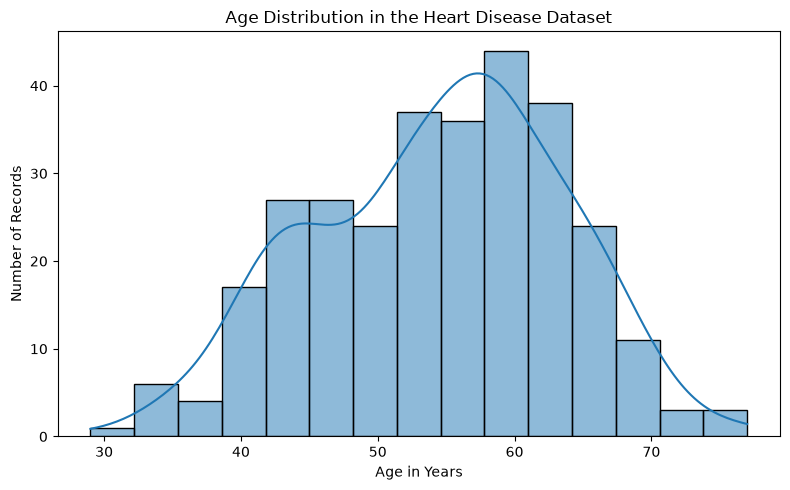

In [34]:
# Visualize the distribution of age
plt.figure(figsize=(8, 5))

sns.histplot(
    data=verified_df,
    x="age",
    bins=15,
    kde=True
)

plt.title("Age Distribution in the Heart Disease Dataset")
plt.xlabel("Age in Years")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "visualizations/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

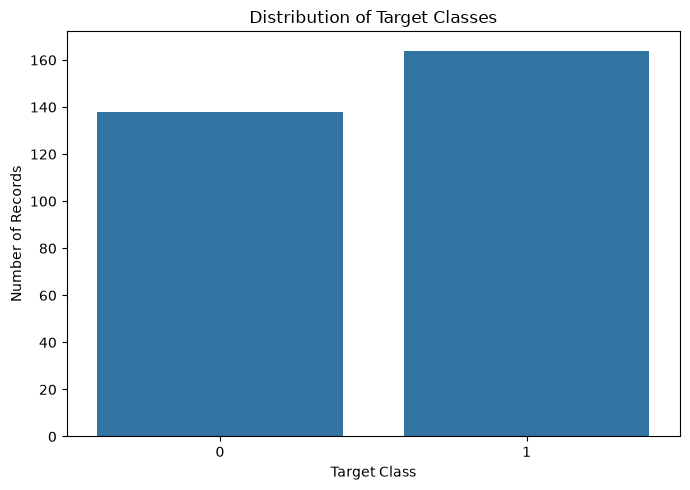

In [35]:
# Count the records in each target category
target_counts = verified_df["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values
)

plt.title("Distribution of Target Classes")
plt.xlabel("Target Class")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "visualizations/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

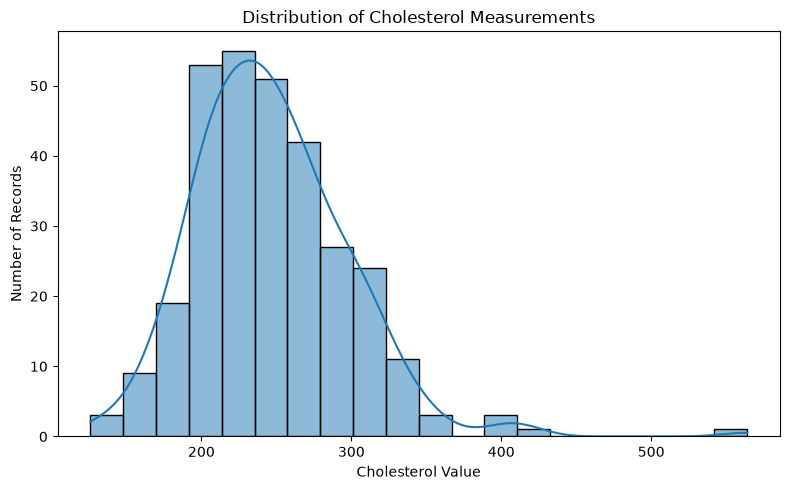

In [36]:
# Visualize cholesterol distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=verified_df,
    x="chol",
    bins=20,
    kde=True
)

plt.title("Distribution of Cholesterol Measurements")
plt.xlabel("Cholesterol Value")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "visualizations/cholesterol_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

9. Correlation Analysis

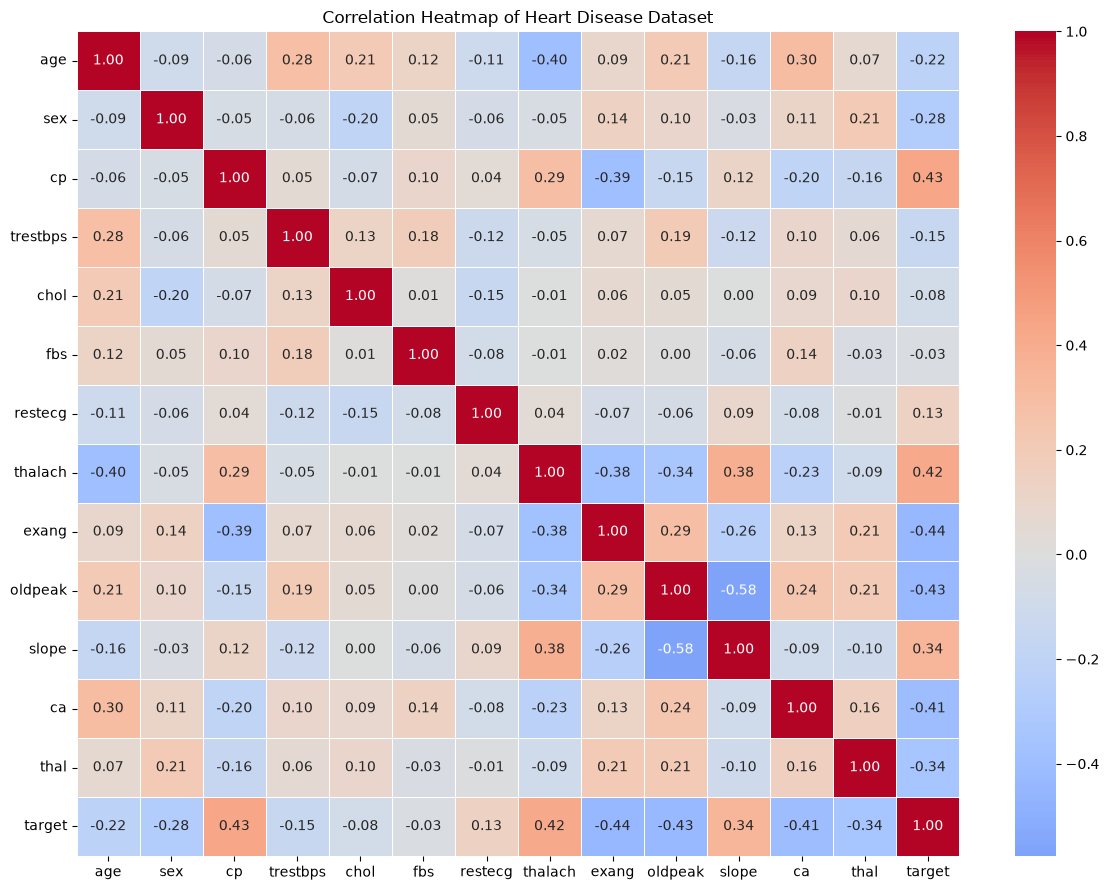

In [37]:
# Select the original numeric-coded columns for correlation analysis
correlation_data = verified_df.select_dtypes(
    include=["number"]
)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.tight_layout()

plt.savefig(
    "visualizations/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

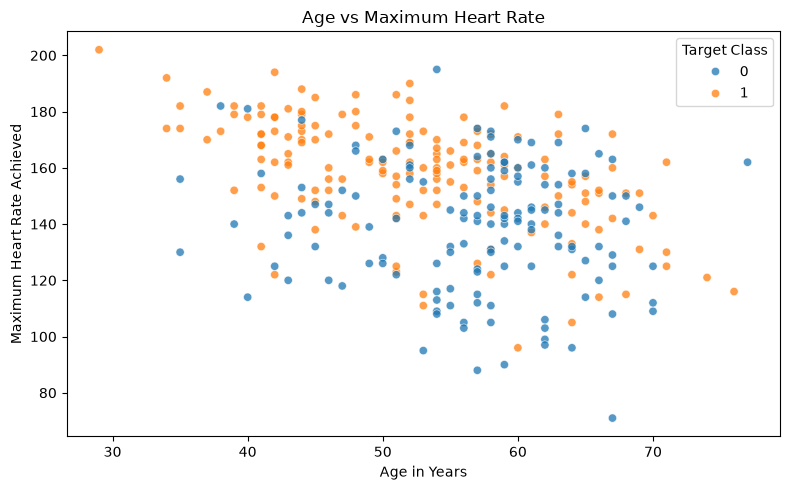

In [38]:
# Examine the relationship between age and maximum heart rate
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=verified_df,
    x="age",
    y="thalach",
    hue="target",
    alpha=0.75
)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age in Years")
plt.ylabel("Maximum Heart Rate Achieved")
plt.legend(title="Target Class")

plt.tight_layout()

plt.savefig(
    "visualizations/age_vs_thalach.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

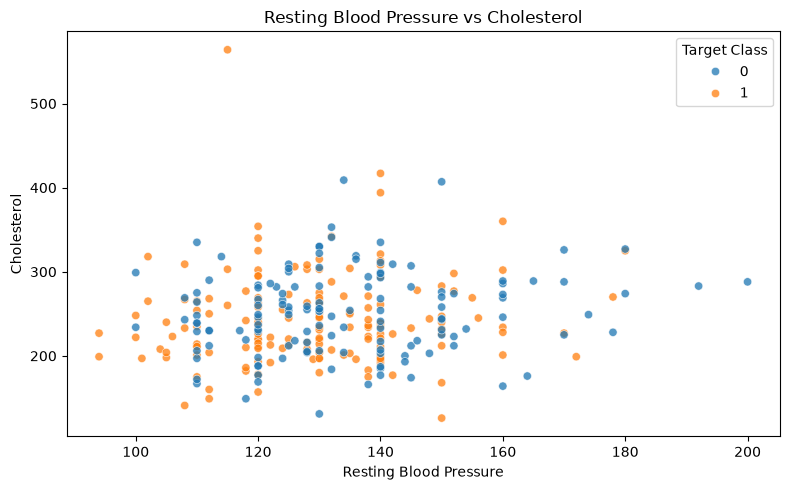

In [39]:
# Examine blood pressure and cholesterol together
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=verified_df,
    x="trestbps",
    y="chol",
    hue="target",
    alpha=0.75
)

plt.title("Resting Blood Pressure vs Cholesterol")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Cholesterol")
plt.legend(title="Target Class")

plt.tight_layout()

plt.savefig(
    "visualizations/blood_pressure_vs_cholesterol.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()